In [1]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

In [34]:
ds_static = xr.open_dataset('/glade/derecho/scratch/turuncu/data/static.nc')
lsm = ds_static.lsm.isel(valid_time=0)

In [8]:
# from https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L40
def _latitude_cell_bounds(x: np.ndarray) -> np.ndarray:
  pi_over_2 = np.array([np.pi / 2], dtype=x.dtype)
  return np.concatenate([-pi_over_2, (x[:-1] + x[1:]) / 2, pi_over_2])
    
# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L45
def _cell_area_from_latitude(points: np.ndarray) -> np.ndarray:
  """Calculate the area overlap as a function of latitude."""
  bounds = _latitude_cell_bounds(points)
  upper = bounds[1:]
  lower = bounds[:-1]
  # normalized cell area: integral from lower to upper of cos(latitude)
  return np.sin(upper) - np.sin(lower)

# From https://github.com/google-research/weatherbench2/blob/021c0b33d9dd165d1e7aa476fcc985be855fbc7b/weatherbench2/metrics.py#L55
def get_lat_weights(ds: xr.Dataset) -> xr.DataArray:
  """Computes latitude/area weights from latitude coordinate of dataset."""
  weights = _cell_area_from_latitude(np.deg2rad(ds.latitude.data))
  weights /= np.mean(weights)
  weights = ds.latitude.copy(data=weights)
  return weights

# Load era5 dataset
ds_era5 = xr.open_dataset(os.path.join(data_path, f"20210101_era5/era5_35d.nc")).rename({'valid_time': 'time'})

# Calculate weights
weights = get_lat_weights(ds_era5)
weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5.longitude.size)))
ds_era5["weights"] = (("latitude", "longitude"), weights2d.data)
weights = np.cos(np.deg2rad(ds_era5.latitude))
weights2d = xr.DataArray(np.tile(weights.values[:,np.newaxis], (1, ds_era5.longitude.size)))
ds_era5["weights2"] = (("latitude", "longitude"), weights2d.data)

JAN
ALT      =  -1.9347577238092422 1.3102080031794139
ERA5     =  -2.053582 1.2773814
OBS-ERA5 =  -0.9972774199512341 1.1055780088891987
AURORA 1 =  -2.0601885 1.2718676
OBS-AUR1 =  -0.9923615119722226 1.1102540081729892
AURORA 2 =  -2.0605984 1.2721416
OBS-AUR2 =  -0.9935890472796299 1.1101254782071117
APR
ALT      =  -1.974107763124905 1.4991607968759229
ERA5     =  -2.084187 1.1639321
OBS-ERA5 =  -0.9763429706187214 0.9348533421685558
AURORA 1 =  -2.0899458 1.1554501
OBS-AUR1 =  -0.9737375510127511 0.941508573286758
AURORA 2 =  -2.0901687 1.1550069
OBS-AUR2 =  -0.9723993969352211 0.9421500030835729
JUL
ALT      =  -2.041255467588272 1.6113659821547264
ERA5     =  -2.1449358 1.4519032
OBS-ERA5 =  -1.1143973949667902 0.9552036299333737
AURORA 1 =  -2.150829 1.4429214
OBS-AUR1 =  -1.1041123750922175 0.9624102487192319
AURORA 2 =  -2.1511776 1.4415841
OBS-AUR2 =  -1.1149585686261403 0.9632767810449765
OCT
ALT      =  -1.9796248698793144 1.5945436861978253
ERA5     =  -2.0969598 1.59350

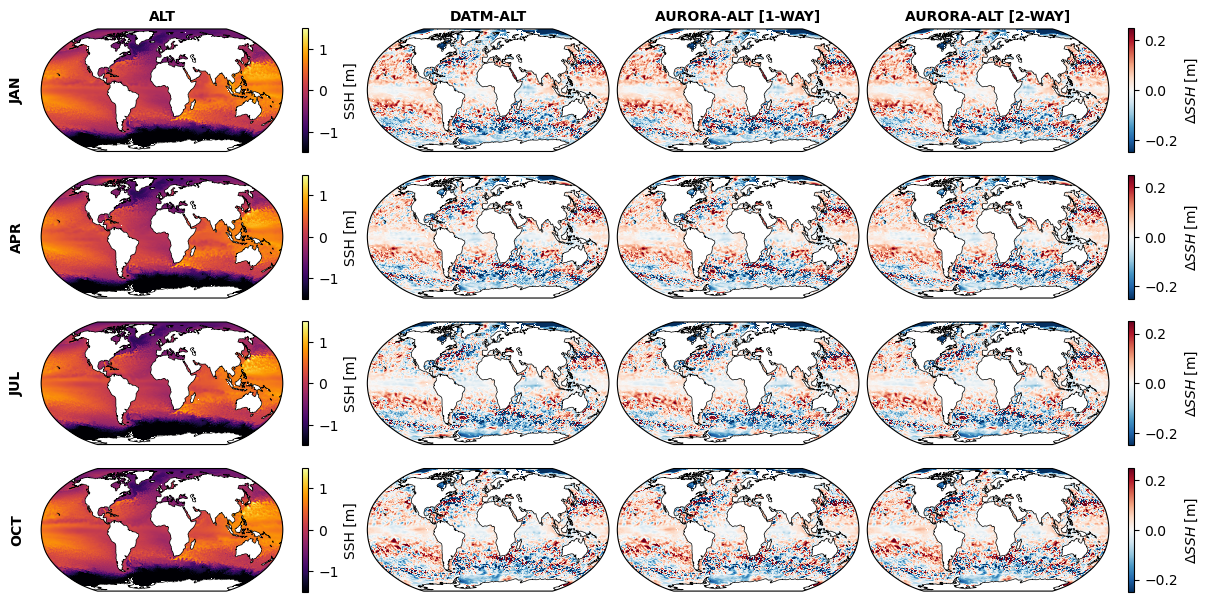

In [35]:
fig, ax = plt.subplots(4, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': ccrs.Robinson()})

irow = 0
for label, val in months.items():
    print(label)
    # Load datasets
    ds_ssh  = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_ssh/ssh_35d_remap_bil.nc"))
    ds_datm = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil.nc"))
    ds_aur1 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil.nc"))
    ds_aur2 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ocn_merged_35d_remap_bil.nc"))

    # Altimetry
    correction = ds_ssh.adt.where(lsm == 0).weighted(ds_era5.weights).mean(["latitude", "longitude"])
    data_ssh = ds_ssh.adt - correction
    data_ssh_mean = data_ssh.mean(["time"])
    print("ALT      = ", data_ssh_mean.min().values, data_ssh_mean.max().values)
    im0 = data_ssh_mean.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-1.5, vmax=1.5, cmap='inferno', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.9, label='SSH [m]')

    # MOM6: ERA5 forced
    data_datm_mean = ds_datm.SSH.where(lsm == 0).mean(["time"])
    data_datm_mean_diff = data_ssh_mean-data_datm_mean
    print('ERA5     = ', data_datm_mean.min().values, data_datm_mean.max().values)
    print('OBS-ERA5 = ', data_datm_mean_diff.min().values, data_datm_mean_diff.max().values)
    im1 = data_datm_mean_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-0.25, vmax=0.25, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)

    # MOM6: Aurora forced (1-way)
    data_aur1_mean = ds_aur1.SSH.where(lsm == 0).mean(["time"])
    data_aur1_mean_diff = data_ssh_mean-data_aur1_mean
    print('AURORA 1 = ', data_aur1_mean.min().values, data_aur1_mean.max().values)
    print('OBS-AUR1 = ', data_aur1_mean_diff.min().values, data_aur1_mean_diff.max().values)
    im2 = data_aur1_mean_diff.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-0.25, vmax=0.25, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)

    # MOM6: Aurora forced (2-way)
    data_aur2_mean = ds_aur2.SSH.where(lsm == 0).mean(["time"])
    data_aur2_mean_diff = data_ssh_mean-data_aur2_mean
    print('AURORA 2 = ', data_aur2_mean.min().values, data_aur2_mean.max().values)
    print('OBS-AUR2 = ', data_aur2_mean_diff.min().values, data_aur2_mean_diff.max().values)
    im3 = data_aur2_mean_diff.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-0.25, vmax=0.25, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    fig.colorbar(im3, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SSH$ [m]')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("ALT", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("DATM-ALT", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AURORA-ALT [1-WAY]", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AURORA-ALT [2-WAY]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

JAN 01
APR 04
JUL 07
OCT 10


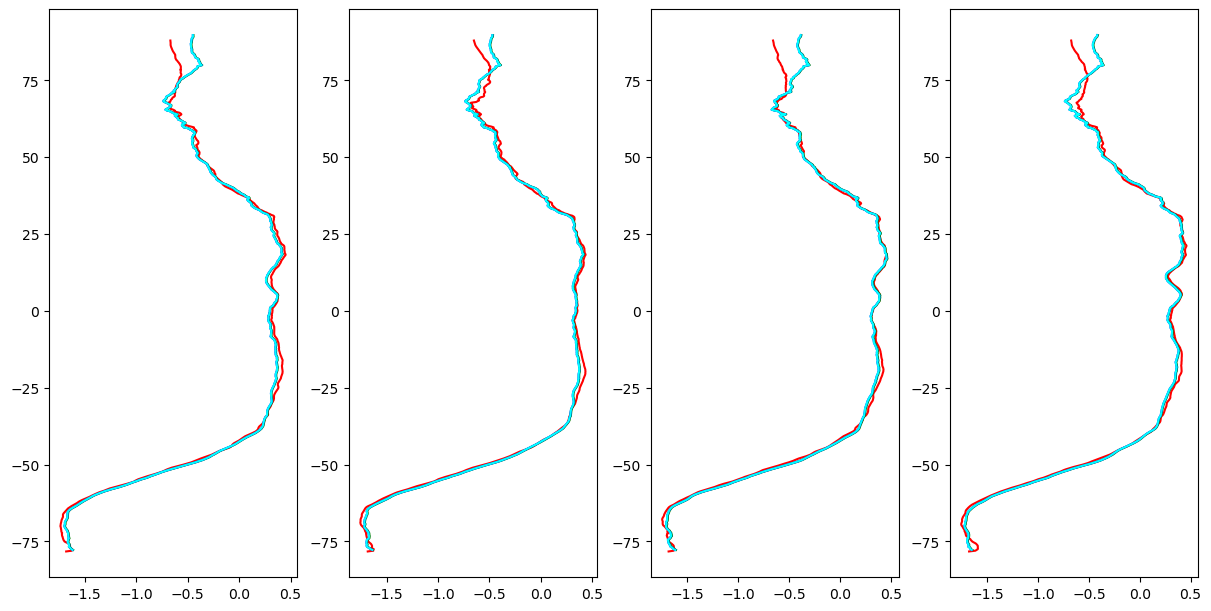

In [44]:
fig, ax = plt.subplots(1, 4, figsize=(12, 6), layout='constrained')
x = ds_era5.latitude.values

indx = 0
for label, val in months.items():
    print(label, f"{val:02d}")
    # Load datasets
    ds_ssh  = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_ssh/ssh_35d_remap_bil.nc"))
    ds_datm = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil.nc"))
    ds_aur1 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ocn_merged_35d_remap_bil.nc"))
    ds_aur2 = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ocn_merged_35d_remap_bil.nc"))

    # Altimetry
    correction = ds_ssh.adt.where(lsm == 0).weighted(ds_era5.weights).mean(["latitude", "longitude"])
    data_ssh = ds_ssh.adt - correction
    data_ssh_mean = data_ssh.weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    im0 = ax[indx].plot(data_ssh_mean, x, color='red', label="ALT")

    # MOM6: ERA5 forced
    data_datm_mean = ds_datm.SSH.where(lsm == 0).weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    im1 = ax[indx].plot(data_datm_mean, x, color='green', label="DATM")

    # MOM6: Aurora forced (1-way)
    data_aur1_mean = ds_aur1.SSH.where(lsm == 0).weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    im2 = ax[indx].plot(data_aur1_mean, x, color='blue', label="AURORA 1w")

    # MOM6: Aurora forced (2-way)
    data_aur2_mean = ds_aur2.SSH.where(lsm == 0).weighted(ds_era5.weights).mean(["longitude"]).mean(["time"])
    im3 = ax[indx].plot(data_aur2_mean, x, color='cyan', label="AURORA 2w")

    indx = indx+1

In [30]:
ds_static = xr.open_dataset('/glade/derecho/scratch/turuncu/data/static.nc')
lsm = ds_static.lsm.isel(valid_time=0)
ds_static

<xarray.Dataset> Size: 12MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2013-01-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    z           (valid_time, latitude, longitude) float32 4MB ...
    lsm         (valid_time, latitude, longitude) float32 4MB ...
    slt         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-16T05:11 GRIB to CDM+CF via cfgrib-0.9.1...

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 140, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2021-01-01T03:00:00 ... 2021-02-04T2...
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    slhf       (time, latitude, longitude) float32 581MB ...
    sshf       (time, latitude, longitude) float32 581MB ...
    ssr        (time, latitude, longitude) float32 581MB ...
    ssrd       (time, latitude, longitude) float32 581MB ...
    str        (time, latitude, longitude) float32 581MB ...
    strd       (time, latitude, longitude) float32 581MB ...
    weights    (latitude, longitude) float64 8MB 721.0 721.0 ... 721.0 721.0
    weights2   (latitude, longitude) float64 8MB 6.123e-17 ... 6.123e-17
Attributes:
    CDI:                     Climate Data Interface version 2.4.4 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Sat Jan 10 16:38:20 2026: cdo selhour,3,9,15,21 ...
    NCO:                     netCDF Operators version 5.3.1 (Homepage = http:...
    CDO:                     Climate Data Operators version 2.4.4 (https://mp...

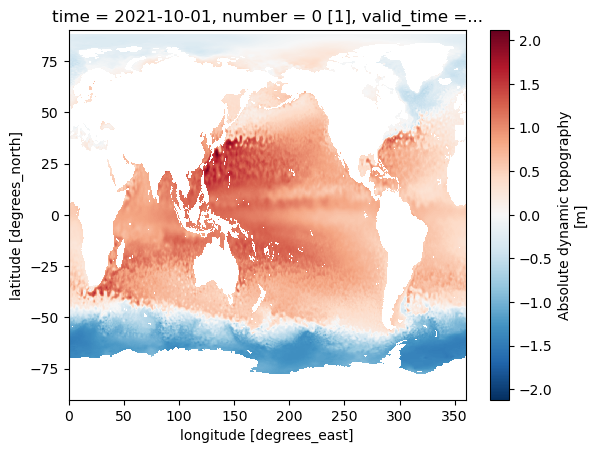

In [31]:
ds_ssh.adt.where(lsm == 0).isel(time=0).plot()
ds_era5

In [32]:
correction = ds_ssh.adt.weighted(ds_era5.weights).mean(["latitude", "longitude"])
print(correction)

<xarray.DataArray 'adt' (time: 35)> Size: 280B
array([0.50920681, 0.50921464, 0.50926897, 0.50936571, 0.5094969 ,
       0.50965532, 0.50983221, 0.51001265, 0.51017593, 0.51030482,
       0.51039686, 0.51046381, 0.51052537, 0.51059962, 0.51069417,
       0.51080104, 0.51089797, 0.51095702, 0.51095724, 0.51089286,
       0.51077647, 0.51063491, 0.510502  , 0.51040925, 0.51037378,
       0.51039251, 0.51045362, 0.51054446, 0.51065251, 0.5107603 ,
       0.51083875, 0.51085137, 0.51076479, 0.51057363, 0.51030788])
Coordinates:
  * time     (time) datetime64[ns] 280B 2021-10-01 2021-10-02 ... 2021-11-04


In [33]:
correction = ds_ssh.adt.where(lsm == 0).weighted(ds_era5.weights).mean(["latitude", "longitude"])
print(correction)

<xarray.DataArray 'adt' (time: 35)> Size: 280B
array([0.50882283, 0.50888137, 0.50897969, 0.50910463, 0.50924461,
       0.5093949 , 0.50955335, 0.50971406, 0.50986488, 0.50999307,
       0.51009555, 0.51017905, 0.51025566, 0.51033604, 0.51042293,
       0.51050744, 0.51057049, 0.51058824, 0.51054221, 0.51042841,
       0.51026158, 0.51007135, 0.5098947 , 0.50976532, 0.50970007,
       0.50969438, 0.50973385, 0.50980336, 0.50988955, 0.50997612,
       0.51003617, 0.51003622, 0.50994531, 0.50975775, 0.50950046])
Coordinates:
  * time        (time) datetime64[ns] 280B 2021-10-01 2021-10-02 ... 2021-11-04
    number      int64 8B 0
    valid_time  datetime64[ns] 8B 2013-01-01
    expver      <U4 16B '0001'
